# Model: Classifier (Stage 1)

The full color-extraction pipeline has three stages: classify each product photo by presentation type, segment the color-bearing region for that type, and extract a CIELAB color value from it. This notebook covers only the first stage, the classifier; segmentation is trained separately and independently in [`06_b_model_segmenters.ipynb`](06_b_model_segmenters.ipynb), and the two are combined only at inference/evaluation time (07, 08). This notebook also prepares the shared annotation data (`data/annotations/labels.csv`) that 06_b reads directly, instead of repeating that work.

**Classifier:** ResNet-18 fine-tuned on seven presentation types:
- `bullet`: a standard twist-up lipstick bullet
- `liquid`: liquid lipstick or gloss, usually in a tube with a wand applicator
- `closed`: a sealed or transparent container, color visible through the packaging
- `swatch`: a flat color swatch, no product shape visible
- `pencil`: a pencil- or crayon-style applicator
- `lips`: color shown applied on real lips rather than on the product
- `unclassifiable`: dead-end cases (a fully sealed container with nothing visible, or a photo showing multiple products, a palette, or not a single product shot); both get the same downstream treatment (no extraction)


**Training history:** Initially, trained the classifier on the original annotation set. Two active-learning loops were run and the training set was expanded (1st round 48 images, 2nd round 13 images). Rather than keep running that incremental correct-and-finetune cycle, the training set was re-designed to add categories like `lips`, `pencil` and tackle coverage, growing to 392 images with the classifier retrained from scratch. 

**Inputs:** `data/processed/annotations_combined.csv`, `data/img/annotation_sample/`, `data/img/annotation_sample_closed/`, `data/processed/products_with_images.csv`, `data/processed/project-4-at-2026-09-18-21-20-25213916.json`, `data/annotations/labels_val.csv` (04_b, for the post-training accuracy check), `data/img/original_clean/`

**Outputs:** `models/resnet18_classifier.pth`, `data/annotations/labels.csv`, `data/annotations/masks/` (the latter two are also read by [`06_b_model_segmenters.ipynb`](06_b_model_segmenters.ipynb))

In [1]:
import os
import sys
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import classification_report, confusion_matrix
warnings.filterwarnings('ignore')

SEED = 42

def seed_everything(seed=SEED):
    """Re-seed every RNG this notebook draws from. Called once here and again
    right before training below."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

seed_everything()

# Resolve project paths relative to BASE, regardless of whether the notebook's
# cwd is the repo root or notebooks/ (works either way it's launched).
BASE = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, BASE)

DATA       = os.path.join(BASE, 'data', 'processed')
IMG        = os.path.join(BASE, 'data', 'img')
ANN_DIR    = os.path.join(BASE, 'data', 'annotations')
MASKS_DIR  = os.path.join(ANN_DIR, 'masks')
MODELS_DIR = os.path.join(BASE, 'models')
IMG_SAMPLE = os.path.join(IMG, 'annotation_sample')
IMG_CLOSED = os.path.join(IMG, 'annotation_sample_closed')
IMG_DIRS   = [IMG_SAMPLE, IMG_CLOSED]

os.makedirs(MASKS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {DEVICE}  |  seed: {SEED}')


device: mps  |  seed: 42


## 1. Data Preparation

Builds the training set (`labels.csv`) from `annotations_combined.csv`, and loads the separate validation set (`labels_val.csv`, from `04_b`) used for the real accuracy check after training. Both are annotated the same way; they differ only in how the underlying images were sampled (see Design Decisions below).

### Training set

In [2]:
CLASSES = ['bullet', 'closed', 'lips', 'liquid', 'pencil', 'swatch', 'unclassifiable']  # sorted alphabetically
CLF_THRESHOLD = 0.6  # below this confidence for ANY class → no extraction (secondary safety net)

# Load the raw annotation set and see how many images fall into each class.
df = pd.read_csv(os.path.join(DATA, 'annotations_combined.csv'))
print(df['label'].value_counts())
print(f'\n{len(df)} training images')


label
swatch            127
bullet             80
liquid             60
closed             47
pencil             31
unclassifiable     29
lips               18
Name: count, dtype: int64

392 training images


In [3]:
# Helpers for locating an image on disk and decoding Label Studio's
# brush-mask RLE format.
from label_studio_converter.brush import decode_rle as _ls_decode_rle

def find_image(img_name, img_dirs=IMG_DIRS):
    """Return the first existing path for img_name across img_dirs, or None
    if it isn't found in any of them."""
    for d in img_dirs:
        p = os.path.join(d, img_name)
        if os.path.exists(p):
            return p
    return None

def decode_rle(rle, height, width):
    """Decode Label Studio brush RLE to a binary mask (H x W, uint8).
    Label Studio encodes brush strokes as RGBA; the mask region is the alpha channel (index 3).
    """
    flat = _ls_decode_rle(rle)           # → length h*w*4, row-major RGBA bytes
    rgba = flat.reshape(height, width, 4)
    return (rgba[:, :, 3] > 0).astype(np.uint8)


In [4]:
import re

def resolve_img_name(img_name):
    """Map a Label Studio img_name to the actual filename on disk.
    When two images shared a base filename, Label Studio appended _XXXXXXX (7 alphanumeric chars)
    before the extension. Strip the suffix to find the real file, but keep the original name for traceability.
    """
    if find_image(img_name) is not None:
        return img_name
    base = re.sub(r'_[A-Za-z0-9]{7}(\.jpg)$', r'\1', img_name)
    if base != img_name and find_image(base) is not None:
        return base
    return None  # unresolvable

# Resolve every row's on-disk filename up front; rows that fail are dropped
# later (they have no image to train or predict on).
df['img_name_disk'] = df['img_name'].apply(resolve_img_name)
found    = df['img_name_disk'].notna().sum()
not_found = df['img_name_disk'].isna().sum()
print(f'{found} images resolved to a file on disk, {not_found} unresolvable')
print(df[['img_name', 'img_name_disk']].head(3))


392 images resolved to a file on disk, 0 unresolvable
                                            img_name  \
0  lipstick__aboutface__paintit_matte_lip_color__...   
1  lipstick__anastasia_beverly_hills__liquid_lips...   
2  lipstick__anastasia_beverly_hills__liquid_lips...   

                                       img_name_disk  
0  lipstick__aboutface__paintit_matte_lip_color__...  
1  lipstick__anastasia_beverly_hills__liquid_lips...  
2  lipstick__anastasia_beverly_hills__liquid_lips...  


In [5]:
# Decode RLE masks from Label Studio JSON → save as PNG in data/annotations/masks/
import glob, hashlib

# Notebook 05's resolve_truncated_name() maps Label Studio's truncated uploads back
# to real catalog names in annotations_combined.csv (df here); see that notebook for
# the full story. task_lookup below must resolve raw task names the same way, or masks
# for every renamed image silently fail to match (this happened: 68 masks skipped).
_MASK_CLEAN = os.path.join(IMG, 'original_clean')
_MASK_LS_UPLOAD_ROOT = os.path.expanduser('~/Library/Application Support/label-studio/media/upload')
_MASK_STAGING_DIRS = [
    IMG_SAMPLE,
    IMG_CLOSED,
    os.path.join(IMG, 'annotation_sample_pencil'),
    os.path.join(IMG, 'annotation_sample_lips_notshown'),
    os.path.join(IMG, 'annotation_sample_style'),
    os.path.join(IMG, 'annotation_sample_color_strat'),
]

def _mask_file_hash(path):
    """MD5 hash of a file's bytes, used to match a Label Studio upload back to
    the staging-folder file it was copied from."""
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

_mask_staging_index_cache = None
def _mask_staging_index():
    """Build (and cache) a content-hash → {filenames} index across every
    staging folder, so an uploaded file's bytes can be traced back to the
    real catalog filename it was staged under."""
    global _mask_staging_index_cache
    if _mask_staging_index_cache is None:
        index = {}
        for d in _MASK_STAGING_DIRS:
            if not os.path.isdir(d):
                continue
            for name in os.listdir(d):
                p = os.path.join(d, name)
                if os.path.isfile(p):
                    index.setdefault(_mask_file_hash(p), set()).add(name)
        _mask_staging_index_cache = index
    return _mask_staging_index_cache

def resolve_task_img_name(img_name):
    """Map a raw Label Studio task image name (possibly a truncated upload)
    back to its real filename in original_clean/, by hashing the uploaded
    file's bytes and looking it up in the staging index. Returns img_name
    unchanged if it can't be resolved."""
    if os.path.exists(os.path.join(_MASK_CLEAN, img_name)):
        return img_name
    upload_matches = glob.glob(os.path.join(_MASK_LS_UPLOAD_ROOT, '*', f'*-{img_name}'))
    if upload_matches:
        target_hash = _mask_file_hash(upload_matches[0])
        staged = {n for n in _mask_staging_index().get(target_hash, set())
                  if os.path.exists(os.path.join(_MASK_CLEAN, n))}
        if len(staged) == 1:
            return next(iter(staged))
    return img_name  # leave as-is if unresolvable, matching notebook 03_c's fallback

with open(os.path.join(DATA, 'project-4-at-2026-09-18-21-20-25213916.json')) as f:
    raw = json.load(f)

# Build img_name -> Label Studio annotation lookup, resolving each task's
# (possibly truncated) image name to the real catalog filename first.
task_lookup = {}
for task in raw:
    img_name = os.path.basename(task['data']['image'])
    img_name = img_name.split('-', 1)[-1] if '-' in img_name else img_name
    img_name = resolve_task_img_name(img_name)
    ann = task['annotations'][0]
    if not ann['result']:
        continue
    task_lookup[img_name] = ann['result'][0]  # store full result entry (h/w are here, not in ['value'])

# Decode each row's mask (if it has one) and save it as a PNG.
saved, skipped = 0, 0
for _, row in df.iterrows():
    stem = os.path.splitext(row['img_name'])[0]
    out_path = os.path.join(MASKS_DIR, stem + '.png')
    if row['img_name'] not in task_lookup:
        skipped += 1
        continue
    entry = task_lookup[row['img_name']]
    rle = entry['value'].get('rle', [])
    h   = entry.get('original_height', 0)
    w   = entry.get('original_width', 0)
    if not rle or not h or not w:
        skipped += 1
        continue
    mask = decode_rle(rle, h, w)
    Image.fromarray(mask * 255).save(out_path)
    saved += 1

print(f'Saved {saved} masks, skipped {skipped}')


Saved 375 masks, skipped 17


In [6]:
# Join with ground-truth LAB values and save data/annotations/labels.csv
products = pd.read_csv(os.path.join(DATA, 'products_with_images.csv'))
gt = products[products['ground_truth_CIELAB'].notna()][['img_name', 'ground_truth_CIELAB']].copy()

# Normalize GT img_names to .jpg — annotation_sample uses original_clean/ which converts everything to .jpg
gt['img_name_disk'] = gt['img_name'].apply(lambda n: os.path.splitext(n)[0] + '.jpg')

def parse_cielab(s):
    """Parse a ground_truth_CIELAB string like '[L a b]' into (true_L, true_a, true_b)."""
    arr = np.fromstring(str(s).strip('[]'), sep=' ')
    return pd.Series({'true_L': arr[0], 'true_a': arr[1], 'true_b': arr[2]})

gt = gt.join(gt['ground_truth_CIELAB'].apply(parse_cielab)).drop(columns=['ground_truth_CIELAB', 'img_name'])

# Join on img_name_disk (resolved filename) so suffix-conflict rows match correctly
labels_df = df.merge(gt, on='img_name_disk', how='left')
labels_df['mask_path'] = labels_df['img_name'].apply(
    lambda n: os.path.join(MASKS_DIR, os.path.splitext(n)[0] + '.png')
)
labels_df.to_csv(os.path.join(ANN_DIR, 'labels.csv'), index=False)
print(labels_df[['img_name', 'img_name_disk', 'label', 'true_L']].head())
print(f'\n{labels_df["true_L"].notna().sum()} / {len(labels_df)} images have ground-truth LAB')


                                            img_name  \
0  lipstick__aboutface__paintit_matte_lip_color__...   
1  lipstick__anastasia_beverly_hills__liquid_lips...   
2  lipstick__anastasia_beverly_hills__liquid_lips...   
3  lipstick__anastasia_beverly_hills__matte_lipst...   
4  lipstick__anastasia_beverly_hills__matte_lipst...   

                                       img_name_disk   label     true_L  
0  lipstick__aboutface__paintit_matte_lip_color__...  swatch   2.677718  
1  lipstick__anastasia_beverly_hills__liquid_lips...  swatch  42.008854  
2  lipstick__anastasia_beverly_hills__liquid_lips...  liquid  27.463101  
3  lipstick__anastasia_beverly_hills__matte_lipst...  bullet  57.439487  
4  lipstick__anastasia_beverly_hills__matte_lipst...  swatch  63.296015  

210 / 392 images have ground-truth LAB


**Training set distribution** is unbalanced: Swatches is the most common type of image and it make up ~32% of annotations. `lips` (18) is the scarcest class overall. The pencil/crayon keyword-oversampling increased `pencil` from 9 to 28. 

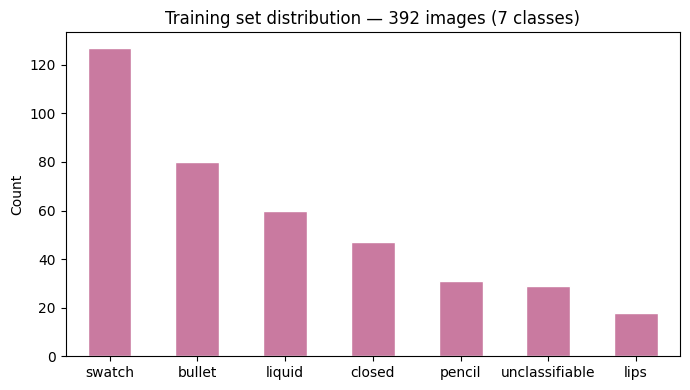

In [7]:
# Bar chart of how many training images fall into each class.
fig, ax = plt.subplots(figsize=(7, 4))
labels_df['label'].value_counts().plot(kind='bar', ax=ax, color='#c97aa0', edgecolor='white')
ax.set_title(f'Training set distribution — {len(labels_df)} images ({len(CLASSES)} classes)')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


### Validation set

`04_b_validation_annotation_image.ipynb` produced an independent validation
set (`data/annotations/labels_val.csv`); see Design Decisions below for why.
Loaded here since it's used right after training. Images live in
`data/img/original_clean/`, not the training image folders above, since
04_a/04_b sampled from the full catalog rather than the Label Studio staging
subset.

In [8]:
# validation set
VAL_IMG_DIR = os.path.join(IMG, 'original_clean')
val_df = pd.read_csv(os.path.join(ANN_DIR, 'labels_val.csv'))
print(f'{len(val_df)} validation images loaded from data/annotations/labels_val.csv (04_b)')
print(val_df['label'].value_counts())


481 validation images loaded from data/annotations/labels_val.csv (04_b)
label
swatch            171
bullet            127
liquid            103
unclassifiable     30
pencil             24
closed             14
lips               12
Name: count, dtype: int64


## 2. Stage 1: Classifier

### Design Decisions

**Training set vs. validation set.** `labels.csv` was built for coverage and to oversample scarce categories, which is good for training but not representative of the real image distribution. `04_a`/`04_b` built a separate, independently-sampled validation set (`labels_val.csv`). Model accuracy on validation set is 0.880.

**Class imbalance.** Weighted cross-entropy loss compensates for the skew shown above: `lips` (18) is the scarcest class, well below `pencil` (28), `closed` (39), or `swatch` (123).

We fine-tune a ResNet-18 on the seven annotated container/presentation types (`bullet`, `liquid`, `closed`, `swatch`, `pencil`, `lips`, `unclassifiable`). Training uses two phases: first the backbone is frozen and only the classification head is trained (5 epochs), then the full network is fine-tuned at a lower learning rate (15 epochs).

**Handling out-of-distribution images:** `unclassifiable` is trained specifically to catch multiple patterns: a fully sealed container with nothing visible, and a photo showing multiple products, a palette, or otherwise not a single clean product shot. That's an explicit, trained catch — a real improvement over the original design, which relied purely on classifier *uncertainty* to catch these cases. Uncertainty isn't a reliable proxy for "doesn't belong to any trained class": a multi-product photo can easily contain something that looks enough like a `bullet` to get a confident, wrong prediction rather than a low-confidence one. The confidence threshold (`CLF_THRESHOLD = 0.6`) is kept as a secondary safety net for images that don't even resemble the `unclassifiable` training examples, i.e. genuinely novel formats not yet seen at all. Both paths lead to the same outcome: no color extracted.

In [9]:
IMG_SIZE_CLS = 224

# Training augmentation (flip + color jitter) vs. plain resize+normalize for
# validation/inference, both otherwise matching ImageNet preprocessing.
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_CLS, IMG_SIZE_CLS)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_CLS, IMG_SIZE_CLS)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class ProductDataset(Dataset):
    """Loads an image by its resolved on-disk filename and returns
    (transformed tensor, class index)."""
    def __init__(self, df, transform):
        # drop rows where the image can't be found on disk
        self.df = df[df['img_name_disk'].notna()].reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(find_image(row['img_name_disk'])).convert('RGB')
        return self.transform(img), CLASSES.index(row['label'])


In [10]:
def build_classifier(num_classes=len(CLASSES), pretrained=True):
    """ResNet-18 pretrained on ImageNet, with the final layer replaced to
    output num_classes logits instead of the original 1000 ImageNet classes."""
    weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    m = models.resnet18(weights=weights)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

# Inverse-frequency class weights, passed to the loss below so training
# doesn't just chase the majority class (`swatch`) at the expense of rarer
# ones like `lips`.
counts = labels_df['label'].value_counts()
total  = len(labels_df)
class_weights = torch.tensor(
    [total / (len(CLASSES) * counts[c]) for c in CLASSES], dtype=torch.float
)
print('Class weights:', {c: round(w, 3) for c, w in zip(CLASSES, class_weights.tolist())})


Class weights: {'bullet': 0.7, 'closed': 1.191, 'lips': 3.111, 'liquid': 0.933, 'pencil': 1.806, 'swatch': 0.441, 'unclassifiable': 1.931}


In [11]:
def run_epoch(model, loader, criterion, optimizer, device, train=True):
    """Run one training or evaluation pass over loader; returns
    (mean loss, accuracy) for that pass."""
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(1) == y).sum().item()
            n          += len(y)
    return total_loss / n, correct / n

def train_classifier(model, train_ds, val_ds, device, ckpt_path):
    """If val_ds is None, trains on 100% of the training set for the fixed
    epoch schedule below and saves the final checkpoint; the separate
    validation set (see Design Decisions above) is used for the real
    accuracy check afterward instead of an internal split."""
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=32, num_workers=0) if val_ds is not None else None

    # Phase 1: freeze backbone
    for p in model.parameters():
        p.requires_grad = False
    for p in model.fc.parameters():
        p.requires_grad = True
    opt = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
    print('Phase 1 — head only (5 epochs)')
    for epoch in range(5):
        _, tr_acc = run_epoch(model, train_loader, criterion, opt, device)
        if val_loader is not None:
            _, va_acc = run_epoch(model, val_loader, criterion, opt, device, train=False)
            print(f'  {epoch+1:2d}: train={tr_acc:.3f}  val={va_acc:.3f}')
        else:
            print(f'  {epoch+1:2d}: train={tr_acc:.3f}')

    # Phase 2: fine-tune all
    for p in model.parameters():
        p.requires_grad = True
    opt = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.1)
    best_val_acc = 0.0
    print('Phase 2 — fine-tune all (15 epochs)')
    for epoch in range(15):
        _, tr_acc = run_epoch(model, train_loader, criterion, opt, device)
        scheduler.step()
        if val_loader is not None:
            _, va_acc = run_epoch(model, val_loader, criterion, opt, device, train=False)
            print(f'  {epoch+1:2d}: train={tr_acc:.3f}  val={va_acc:.3f}')
            if va_acc > best_val_acc:
                best_val_acc = va_acc
                torch.save({'model_state_dict': model.state_dict(), 'classes': CLASSES}, ckpt_path)
        else:
            print(f'  {epoch+1:2d}: train={tr_acc:.3f}')

    if val_loader is None:
        torch.save({'model_state_dict': model.state_dict(), 'classes': CLASSES}, ckpt_path)
        print(f'\nFinal train acc: {tr_acc:.3f}  →  {ckpt_path}  (see Design Decisions above for real accuracy on the validation set)')
    else:
        print(f'\nBest val acc: {best_val_acc:.3f}  →  {ckpt_path}')


In [12]:
# Train on 100% of the training set; the separate validation set (see
# Design Decisions above) is used for the real accuracy check afterward.
train_df = labels_df[labels_df['img_name_disk'].notna()].reset_index(drop=True)

print(f'Train: {len(train_df)}  (100% of the training set)')
print('\nTrain label distribution:')
print(train_df['label'].value_counts().to_string())

seed_everything()
clf = build_classifier(num_classes=len(CLASSES)).to(DEVICE)
clf_ckpt = os.path.join(MODELS_DIR, 'resnet18_classifier.pth')
train_classifier(clf, ProductDataset(train_df, train_tf), None, DEVICE, clf_ckpt)

Train: 392  (100% of the training set)

Train label distribution:
label
swatch            127
bullet             80
liquid             60
closed             47
pencil             31
unclassifiable     29
lips               18


Phase 1 — head only (5 epochs)


   1: train=0.224


   2: train=0.556


   3: train=0.724


...

  11: train=1.000


  12: train=1.000


  13: train=1.000


  14: train=1.000


  15: train=1.000

Final train acc: 1.000  →  /Users/connie/dev/lipstick_color_extraction/models/resnet18_classifier.pth  (see Design Decisions above for real accuracy on the validation set)


**Real accuracy check** (see Design Decisions above): the cell below scores the just-trained classifier against `labels_val.csv`.

In [13]:
# Score the just-trained classifier against the independent validation set
# (see Design Decisions above for why this, and not an internal split, is
# the real accuracy number).
clf.eval()
true_labels, pred_labels = [], []
for _, row in val_df.iterrows():
    img_path = find_image(row['img_name_disk'], img_dirs=(VAL_IMG_DIR,))
    if img_path is None:
        continue
    img = Image.open(img_path).convert('RGB')
    with torch.no_grad():
        probs = torch.softmax(clf(val_tf(img).unsqueeze(0).to(DEVICE)), dim=1).squeeze().cpu().numpy()
    true_labels.append(row['label'])
    pred_labels.append(CLASSES[probs.argmax()])

n = len(true_labels)
correct = sum(t == p for t, p in zip(true_labels, pred_labels))
print(f'Validation accuracy (labels_val.csv, N={n}): {correct/n:.3f}')


Validation accuracy (labels_val.csv, N=483): 0.880


**Per-class metrics and confusion matrix**, computed on the same validation predictions above: accuracy, false-negative rate, and false-positive rate per class (each with a Wilson 95% confidence interval), the full `classification_report`, and a confusion matrix.

                n_true  n_pred  accuracy      acc_95ci  fn_rate       fn_95ci  fp_rate       fp_95ci
class                                                                                               
bullet             127     149     0.992  [0.96, 1.00]    0.008  [0.00, 0.04]    0.154  [0.11, 0.22]
closed              17      24     0.706  [0.47, 0.87]    0.294  [0.13, 0.53]    0.500  [0.31, 0.69]
lips                12      13     1.000  [0.76, 1.00]    0.000  [0.00, 0.24]    0.077  [0.01, 0.33]
liquid             103     102     0.913  [0.84, 0.95]    0.087  [0.05, 0.16]    0.078  [0.04, 0.15]
pencil              24      21     0.792  [0.60, 0.91]    0.208  [0.09, 0.40]    0.095  [0.03, 0.29]
swatch             171     150     0.871  [0.81, 0.91]    0.129  [0.09, 0.19]    0.007  [0.00, 0.04]
unclassifiable      29      24     0.448  [0.28, 0.62]    0.552  [0.38, 0.72]    0.458  [0.28, 0.65]

classification_report:
                precision    recall  f1-score   support

        bu

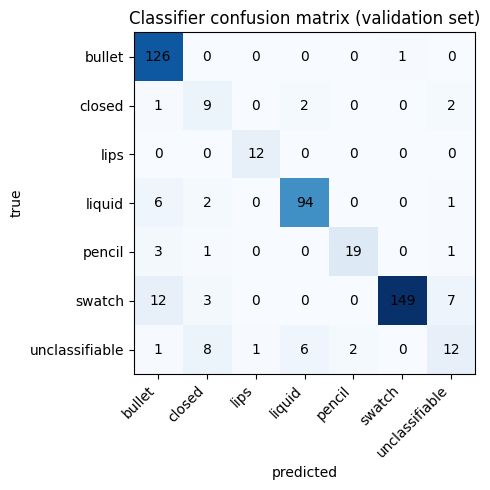

In [14]:
# Wilson score interval for a binomial proportion — see src/metrics.py.
from src.metrics import wilson

true_arr = np.array(true_labels)
pred_arr = np.array(pred_labels)

# Per-class accuracy, false-negative rate, and false-positive rate, each with
# a Wilson 95% CI.
rows = []
for c in CLASSES:
    tc = true_arr == c
    pc = pred_arr == c
    acc_p, acc_lo, acc_hi = wilson((pred_arr[tc] == c).sum(), tc.sum())
    fn_p, fn_lo, fn_hi = wilson((pred_arr[tc] != c).sum(), tc.sum())
    fp_p, fp_lo, fp_hi = wilson((true_arr[pc] != c).sum(), pc.sum())
    rows.append({
        'class': c, 'n_true': int(tc.sum()), 'n_pred': int(pc.sum()),
        'accuracy': acc_p, 'acc_95ci': f'[{acc_lo:.2f}, {acc_hi:.2f}]',
        'fn_rate': fn_p, 'fn_95ci': f'[{fn_lo:.2f}, {fn_hi:.2f}]',
        'fp_rate': fp_p, 'fp_95ci': f'[{fp_lo:.2f}, {fp_hi:.2f}]',
    })
clf_metrics = pd.DataFrame(rows).set_index('class')
print(clf_metrics.to_string(float_format=lambda x: f'{x:.3f}'))

print('\nclassification_report:')
print(classification_report(true_labels, pred_labels, labels=CLASSES, target_names=CLASSES, zero_division=0))

# Confusion matrix: predicted class (columns) vs. true class (rows).
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(true_labels, pred_labels, labels=CLASSES)
ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=45, ha='right')
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
for (r, cc), v in np.ndenumerate(cm):
    ax.text(cc, r, v, ha='center', va='center')
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title('Classifier confusion matrix (validation set)')
plt.tight_layout()
plt.show()


**Reading the results:** overall accuracy is 0.880, but two classes pull down the macro average (0.80 vs. 0.88 weighted). `unclassifiable` has recall 0.45 (most `unclassifiable` images still get predicted as a real class instead) and `closed` has precision 0.50 (about half of images predicted `closed` are actually something else) — both improved after a couple of `unclassifiable`→`closed` ground-truth corrections landed in the validation set. `closed` still has the smallest validation count after `lips` (n=17), so its Wilson CI above stays wide — noisy on top of weak. Every other class scores 0.84+ F1, with `bullet` and `lips` near-perfect on recall.